In [8]:
# DecodeLab Data_Analytics project 1
import pandas as pd
import numpy as np
import seaborn as sns

In [11]:
#load dataset
df = pd.read_csv("C:/Users/urmee/OneDrive/Vis_studio/Dataset for Data Analytics (1).csv")
print("=" *30)
print("Step-1:Initial Data Audit")
print("=" *30)
df.info()
df.describe(include="all")
df.head(10)

Step-1:Initial Data Audit
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,NaN,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52


Available columns: ['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


<Axes: xlabel='TotalPrice', ylabel='Count'>

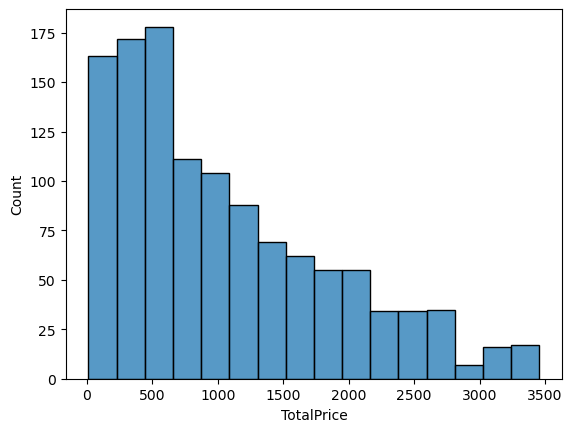

In [18]:
#plot distribution
print ("Available columns:" , df.columns.tolist())
sns.histplot(df['TotalPrice'])

In [80]:
# Convert price columns to numeric format, handling any string formatting
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
df['TotalPrice'] = pd.to_numeric(df['TotalPrice'], errors='coerce')

# Alternative: If prices have currency symbols or commas, remove them first
df['UnitPrice'] = df['UnitPrice'].astype(str).str.replace('[$,]', '', regex=True)
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')

df['TotalPrice'] = df['TotalPrice'].astype(str).str.replace('[$,]', '', regex=True)
df['TotalPrice'] = pd.to_numeric(df['TotalPrice'], errors='coerce')

In [81]:
# Convert price columns to numeric format, handling any string formatting
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
df['TotalPrice'] = pd.to_numeric(df['TotalPrice'], errors='coerce')

# Alternative: If prices have currency symbols or commas, remove them first
df['UnitPrice'] = df['UnitPrice'].astype(str).str.replace('[$,]', '', regex=True)
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')

df['TotalPrice'] = df['TotalPrice'].astype(str).str.replace('[$,]', '', regex=True)
df['TotalPrice'] = pd.to_numeric(df['TotalPrice'], errors='coerce')

In [21]:
print("\n❓ MISSING VALUES")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Count': missing, '%': missing_pct}))


❓ MISSING VALUES
                 Count      %
OrderID              0   0.00
Date                 0   0.00
CustomerID           0   0.00
Product              0   0.00
Quantity             0   0.00
UnitPrice            0   0.00
ShippingAddress      0   0.00
PaymentMethod        0   0.00
OrderStatus          0   0.00
TrackingNumber       0   0.00
ItemsInCart          0   0.00
CouponCode         309  25.75
ReferralSource       0   0.00
TotalPrice           0   0.00


In [47]:
df['CouponCode'].notnull().sum()  # Returns count of non-missing values

np.int64(891)

In [55]:
df['CouponCode'] = df['CouponCode'].fillna('NO_COUPON')

In [56]:
df['CouponCode'].isnull().sum()  # Returns the number of missing values

np.int64(0)

In [58]:
df.duplicated().sum()  # Returns the number of duplicate rows

np.int64(0)

In [59]:
print("  STEP 4 — CORRECTING DATA FORMATS")
print("=" * 60)

  STEP 4 — CORRECTING DATA FORMATS


In [98]:
import pandas as pd  # Import pandas library first

# Convert to datetime and extract date only
df['Date'] = pd.to_datetime(df['Date']).dt.date


In [99]:
print("First 5:")
print(df['Date'].head())
print("\nLast 5:")
print(df['Date'].tail())

First 5:
0    2023-01-04
1    2024-08-23
2    2024-02-27
3    2023-10-15
4    2025-05-08
Name: Date, dtype: object

Last 5:
1195    2024-06-20
1196    2024-03-04
1197    2023-07-13
1198    2024-08-22
1199    2023-06-11
Name: Date, dtype: object


In [100]:
df.dtypes  # See all column types
df.info()  # Detailed info including memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [101]:
# Convert price columns to numeric format, handling any string formatting
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
df['TotalPrice'] = pd.to_numeric(df['TotalPrice'], errors='coerce')


In [102]:
# Check data types of all columns
print(df.dtypes)

# Check data types of specific price columns
print(df[['UnitPrice', 'TotalPrice']].dtypes)

# Get detailed information about the DataFrame
print(df.info())

# Check for non-numeric values in specific columns
print(df['UnitPrice'].apply(lambda x: str(x).replace('.','').replace('-','').isdigit()).all())
print(df['TotalPrice'].apply(lambda x: str(x).replace('.','').replace('-','').isdigit()).all())

# Display sample values to see the format
print(df[['UnitPrice', 'TotalPrice']].head())

# Check if columns are numeric using pandas
print(pd.api.types.is_numeric_dtype(df['UnitPrice']))
print(pd.api.types.is_numeric_dtype(df['TotalPrice']))

OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object
UnitPrice     float64
TotalPrice    float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 no

In [103]:
# Identify text/object columns
text_columns = df.select_dtypes(include=['object']).columns
print("Text columns:", text_columns.tolist())

# Clean text data format
for col in text_columns:
    # Remove leading/trailing whitespace
    df[col] = df[col].astype(str).str.strip()
    
    # Convert to proper case (capitalize first letter of each word)
    df[col] = df[col].str.title()
    
    # Remove extra spaces between words
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)
    
    # Handle missing values
    df[col] = df[col].replace('Nan', pd.NA)

# Alternative: More specific text cleaning
# Remove special characters (keep only letters, numbers, spaces)
df[text_columns] = df[text_columns].replace(r'[^a-zA-Z0-9\s]', '', regex=True)

# Convert all text to lowercase
df[text_columns] = df[text_columns].apply(lambda x: x.str.lower())

# Or convert to uppercase
df[text_columns] = df[text_columns].apply(lambda x: x.str.upper())

# Check the cleaned format
print(df[text_columns].head())

Text columns: ['OrderID', 'Date', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource']
     OrderID      Date CustomerID  Product ShippingAddress PaymentMethod  \
0  ORD200000  20230104     C72649  MONITOR     928 MAIN ST    DEBIT CARD   
1  ORD200001  20240823     C75739    PHONE     823 MAIN ST        ONLINE   
2  ORD200002  20240227     C81728   TABLET     512 MAIN ST   CREDIT CARD   
3  ORD200003  20231015     C33540    CHAIR     275 MAIN ST    DEBIT CARD   
4  ORD200004  20250508     C81840  PRINTER     668 MAIN ST        ONLINE   

  OrderStatus TrackingNumber CouponCode ReferralSource  
0     SHIPPED    TRK37947903     SAVE10      INSTAGRAM  
1     SHIPPED    TRK91186779     SAVE10       REFERRAL  
2   CANCELLED    TRK42903982   FREESHIP          EMAIL  
3    RETURNED    TRK62788070     SAVE10       FACEBOOK  
4   DELIVERED    TRK29241424     SAVE10          EMAIL  


In [104]:
# 1. Overall DataFrame information
print("=== DATAFRAME OVERVIEW ===")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n")

# 2. Data types check
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n")

# 3. Missing values analysis
print("=== MISSING VALUES ===")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])
print("\n")

# 4. Duplicate rows check
print("=== DUPLICATES ===")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print("\n")

# 5. Data quality summary
print("=== DATA QUALITY SUMMARY ===")
print(df.describe(include='all'))
print("\n")

# 6. Check for inconsistent data
print("=== INCONSISTENCY CHECKS ===")
# Check for mixed data types in object columns
for col in df.select_dtypes(include=['object']).columns:
    unique_types = df[col].apply(type).unique()
    if len(unique_types) > 1:
        print(f"Column '{col}' has mixed data types: {unique_types}")

# 7. Final validation
print("=== FINAL VALIDATION ===")
print(f"✓ Total rows: {len(df)}")
print(f"✓ Total columns: {len(df.columns)}")
print(f"✓ Complete cases (no missing values): {df.dropna().shape[0]}")
print(f"✓ Data is ready: {df.isnull().sum().sum() == 0 and duplicates == 0}")

=== DATAFRAME OVERVIEW ===
Shape: (1200, 14)
Memory usage: 0.69 MB


=== DATA TYPES ===
OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object


=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


=== DUPLICATES ===
Number of duplicate rows: 0


=== DATA QUALITY SUMMARY ===
          OrderID      Date CustomerID  Product     Quantity    UnitPrice  \
count        1200      1200       1200     1200  1200.000000  1200.000000   
unique       1200       671       1189        7          NaN          NaN   
top     ORD200000  20230820     C38840  PRINTER          NaN          NaN   
freq            1         8         

In [105]:
# 1. Save as CSV file
df.to_csv('cleaned_data.csv', index=False)
print("Data saved as CSV file: cleaned_data.csv")

# 2. Save as Excel file
df.to_excel('cleaned_data.xlsx', index=False, sheet_name='CleanedData')
print("Data saved as Excel file: cleaned_data.xlsx")
# 3. Save with specific options (CSV example)
df.to_csv('cleaned_data_custom.csv', 
          index=False,           # Don't include row indices
          sep=',',              # Comma separator
          encoding='utf-8',     # UTF-8 encoding
          na_rep='NULL')        # Replace NaN with 'NULL'

# 4. For Jupyter Notebook - trigger download
from IPython.display import FileLink
df.to_csv('download_data.csv', index=False)
FileLink('download_data.csv')

Data saved as CSV file: cleaned_data.csv
Data saved as Excel file: cleaned_data.xlsx


C:\Users\urmee\download_data.csv

In [106]:
from IPython.display import FileLink
df.to_excel('my_data.xlsx', index=False)
FileLink('my_data.xlsx')

C:\Users\urmee\my_data.xlsx